# Analysis: Investigating Crisis Call Volumes — Eugene vs. Springfield
**Author:** Ilhan Haniff  
**Description:** This notebook conducts the full analysis for the project, including exploratory data analysis, temporal pattern analysis, and a pre/post CAHOOTS discontinuation analysis.

**Inputs:**
- `data/cad_clean_2015_2025.csv` — Cleaned Eugene CAD data
- `data/spd_clean_2015_2025.csv` — Cleaned SPD Responding Units data

**Outputs:**
- Summary tables of call volumes by agency and year
- Line plots of yearly call volume trends by agency
- Faceted line plot: call volume by hour of day, Eugene vs. Springfield
- Grouped bar chart: agency share before vs. after April 7, 2025
- Annotated line plot with CAHOOTS discontinuation marker

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Styling the plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Load Cleaned Datasets

In [2]:
cad = pd.read_csv(os.path.join('data', 'cad_clean_2015_2025.csv'), parse_dates=['calltime'])
spd = pd.read_csv(os.path.join('data', 'spd_clean_2015_2025.csv'), parse_dates=['calltime'])

print(f'CAD shape: {cad.shape}')
print(f'SPD shape: {spd.shape}')
cad.head(3)
spd["unit_type"].unique()

CAD shape: (1446014, 9)
SPD shape: (567655, 9)


array(['PATROL', 'UNKNOWN', 'OTHER', 'CSO_AC', 'DETECTIVE', 'CAHOOTS',
       'NOT_SPD', 'COMMAND'], dtype=object)

---
## Part 1: Exploratory Data Analysis (EDA)

### 1.1 Summary Statistics — Eugene CAD

In [3]:
# Total call counts by unit_type
print('=== Eugene CAD: Call counts by unit_type ===')
print(cad['unit_type'].value_counts())
print(f'\nTotal calls: {len(cad):,}')

=== Eugene CAD: Call counts by unit_type ===
unit_type
EPD        933692
UNKNOWN    354283
CAHOOTS    158039
Name: count, dtype: int64

Total calls: 1,446,014


In [4]:
# Call counts by unit_type and year
print('=== Eugene CAD: Call counts by unit_type and year ===')
cad_yearly_summary = cad.groupby(['call_year', 'unit_type']).size().unstack(fill_value=0)
print(cad_yearly_summary)

=== Eugene CAD: Call counts by unit_type and year ===
unit_type  CAHOOTS    EPD  UNKNOWN
call_year                         
2015          9547  89514    24187
2016         10989  87816    28927
2017         14122  84524    31042
2018         15055  80790    31587
2019         16414  84621    36054
2020         16534  88017    32736
2021         16746  86000    34781
2022         20317  83104    37124
2023         17354  82963    35147
2024         16532  82954    33164
2025          4429  83389    29534


In [76]:
# Average daily Eugene CAHOOTS calls across full pre-discontinuation period
eugene_cahoots_all = cad[
    (cad['unit_type'] == 'CAHOOTS') &
    (cad['calltime'] < pd.Timestamp('2025-04-07'))
]

full_pre_daily = eugene_cahoots_all.groupby(
    eugene_cahoots_all['calltime'].dt.date
).size()

print(f'Average daily Eugene CAHOOTS calls (full 2015–Apr 2025): {full_pre_daily.mean():.1f}')

Average daily Eugene CAHOOTS calls (full 2015–Apr 2025): 42.2


### 1.2 Summary Statistics — SPD

In [5]:
# Total call counts by unit_type
print('=== SPD: Call counts by unit_type ===')
print(spd['unit_type'].value_counts())
print(f'\nTotal calls: {len(spd):,}')

=== SPD: Call counts by unit_type ===
unit_type
PATROL       360946
UNKNOWN       79587
OTHER         44990
CAHOOTS       44380
CSO_AC        34200
DETECTIVE      3281
COMMAND         209
NOT_SPD          62
Name: count, dtype: int64

Total calls: 567,655


In [6]:
# Call counts by unit_type and year
print('=== SPD: Call counts by unit_type and year ===')
spd_yearly_summary = spd.groupby(['call_year', 'unit_type']).size().unstack(fill_value=0)
print(spd_yearly_summary)

=== SPD: Call counts by unit_type and year ===
unit_type  CAHOOTS  COMMAND  CSO_AC  DETECTIVE  NOT_SPD  OTHER  PATROL  \
call_year                                                                
2015          1630       22    3245        366        3   6017   36454   
2016          2369       22    3553        310        5   5078   37728   
2017          3213       39    2727        443        3   5634   38147   
2018          4286       20    3075        361        5   5354   34818   
2019          4894        4    3252        324        2   5187   34382   
2020          5408       12    2553        275        5   3638   31271   
2021          5640       15    2734        268        1   4501   28941   
2022          5620        6    2934        217        1   4493   28420   
2023          5382       14    3054        216        2   2547   29585   
2024          3586       39    3189        244       11   1482   31437   
2025          2352       16    3884        257       24   1059   

In [7]:
# Overall distributions
print('=== Eugene CAD: describe ===')
print(cad[['call_year', 'call_hour']].describe())
print('\n=== SPD: describe ===')
print(spd[['call_year', 'call_hour']].describe())

=== Eugene CAD: describe ===
          call_year     call_hour
count  1.446014e+06  1.446014e+06
mean   2.020024e+03  1.290527e+01
std    3.101897e+00  6.176294e+00
min    2.015000e+03  0.000000e+00
25%    2.017000e+03  9.000000e+00
50%    2.020000e+03  1.300000e+01
75%    2.023000e+03  1.800000e+01
max    2.025000e+03  2.300000e+01

=== SPD: describe ===
           call_year      call_hour
count  567655.000000  567655.000000
mean     2019.773952      13.014197
std         3.133205       6.496482
min      2015.000000       0.000000
25%      2017.000000       9.000000
50%      2020.000000      14.000000
75%      2022.000000      18.000000
max      2025.000000      23.000000


---
## Part 2: Temporal Pattern Analysis
*Addresses Sub-question 1: How do call volumes vary over time and by hour between Eugene and Springfield?*

### 2.1 Yearly Call Volume Trends — Eugene

In [8]:
# Aggregate yearly call volumes by unit_type
cad_yearly = cad.groupby(['call_year', 'unit_type']).size().reset_index(name='call_count')
print(cad_yearly.head(10))

   call_year unit_type  call_count
0       2015   CAHOOTS        9547
1       2015       EPD       89514
2       2015   UNKNOWN       24187
3       2016   CAHOOTS       10989
4       2016       EPD       87816
5       2016   UNKNOWN       28927
6       2017   CAHOOTS       14122
7       2017       EPD       84524
8       2017   UNKNOWN       31042
9       2018   CAHOOTS       15055


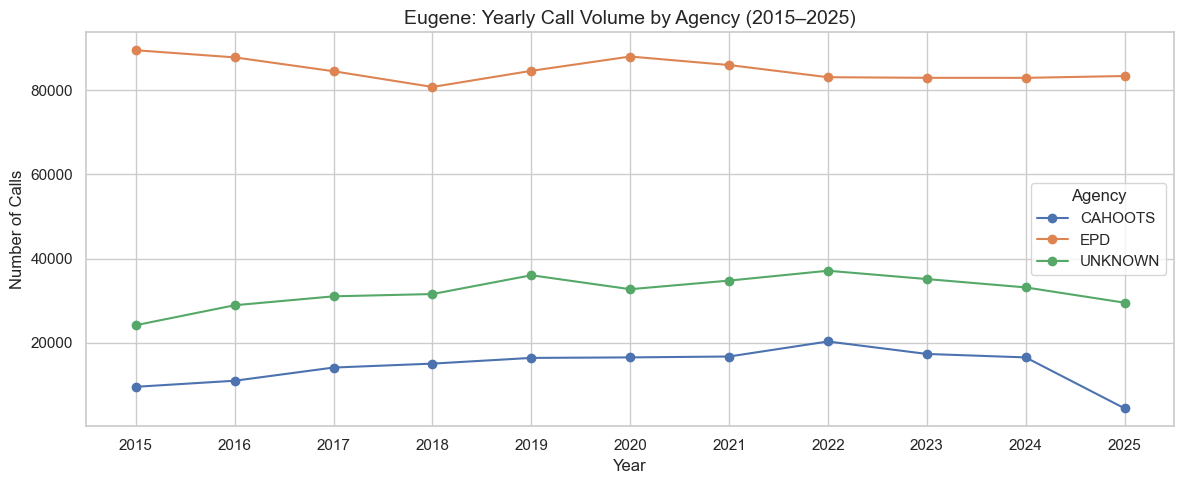

In [60]:
# Line plot: yearly call volume trends by agency (Eugene)
fig, ax = plt.subplots()

for unit in cad_yearly['unit_type'].unique():
    subset = cad_yearly[cad_yearly['unit_type'] == unit]
    ax.plot(subset['call_year'], subset['call_count'], marker='o', label=unit)

ax.set_title('Eugene: Yearly Call Volume by Agency (2015–2025)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Calls')
ax.legend(title='Agency')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('figures/eugene_yearly_call_volume.png', dpi=150)
plt.show()

### 2.2 Yearly Call Volume Trends — Springfield

In [10]:
# Aggregate yearly call volumes by unit_type
spd_yearly = spd.groupby(['call_year', 'unit_type']).size().reset_index(name='call_count')
print(spd_yearly.head(10))

   call_year  unit_type  call_count
0       2015    CAHOOTS        1630
1       2015    COMMAND          22
2       2015     CSO_AC        3245
3       2015  DETECTIVE         366
4       2015    NOT_SPD           3
5       2015      OTHER        6017
6       2015     PATROL       36454
7       2015    UNKNOWN        7067
8       2016    CAHOOTS        2369
9       2016    COMMAND          22


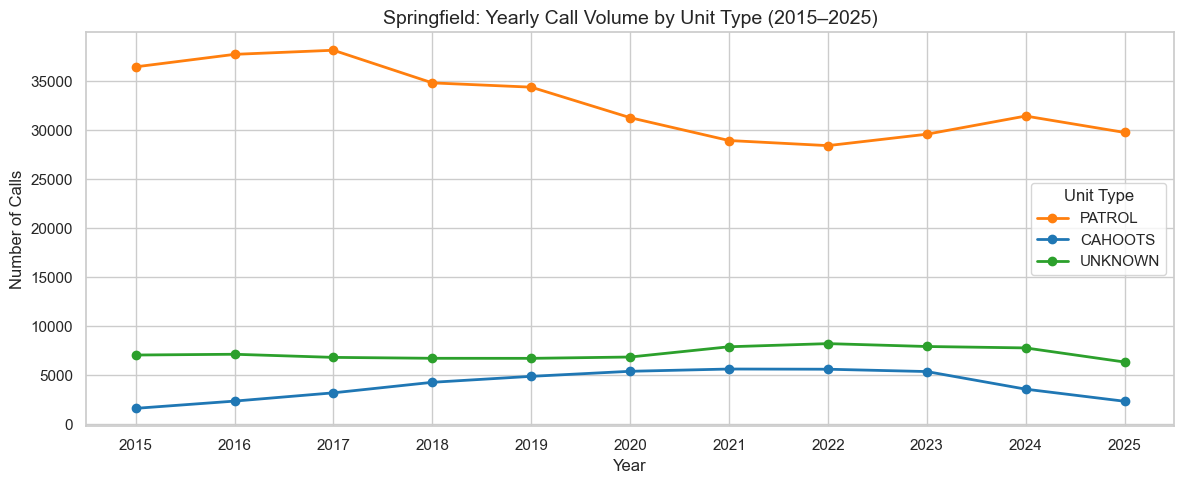

In [64]:
# Filter to only CAHOOTS, PATROL, and UNKNOWN
spd_yearly_filtered = spd_yearly[spd_yearly['unit_type'].isin(['CAHOOTS', 'PATROL', 'UNKNOWN'])]

# Line plot: yearly call volume trends — Springfield
fig, ax = plt.subplots()

for unit in ['PATROL', 'CAHOOTS', 'UNKNOWN']:
    subset = spd_yearly_filtered[spd_yearly_filtered['unit_type'] == unit]
    ax.plot(subset['call_year'], subset['call_count'],
            marker='o', label=unit, linewidth=2, color=colors[unit])

colors = {
    'PATROL':  '#ff7f0e',   
    'CAHOOTS': '#1f77b4',  
    'UNKNOWN': '#2ca02c'    
}

ax.set_title('Springfield: Yearly Call Volume by Unit Type (2015–2025)', fontsize=14)
ax.set_xlabel('Year')

ax.set_ylabel('Number of Calls')
ax.legend(title='Unit Type')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('figures/spd_yearly_call_volume.png', dpi=150)
plt.show()

### 2.3 Hourly Call Volume Patterns — Eugene vs. Springfield

In [12]:
# Aggregate hourly call volumes by unit_type
cad_hourly = cad.groupby(['call_hour', 'unit_type']).size().reset_index(name='call_count')
spd_hourly = spd.groupby(['call_hour', 'unit_type']).size().reset_index(name='call_count')

print('Eugene hourly sample:')
print(cad_hourly.head(5))

Eugene hourly sample:
   call_hour unit_type  call_count
0          0   CAHOOTS        5093
1          0       EPD       38105
2          0   UNKNOWN        7058
3          1   CAHOOTS        4465
4          1       EPD       31642


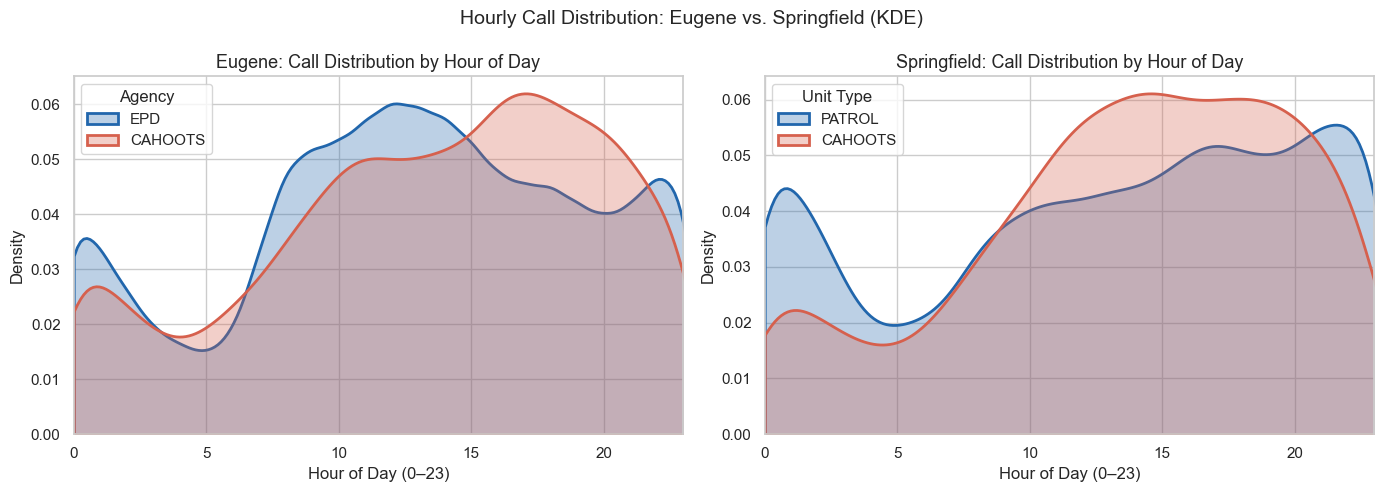

In [15]:
# KDE plot: hourly call distribution by agency — Eugene vs. Springfield
cad_main = cad[cad['unit_type'].isin(['EPD', 'CAHOOTS'])]
spd_main = spd[spd['unit_type'].isin(['PATROL', 'CAHOOTS'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eugene panel
for unit, color in zip(['EPD', 'CAHOOTS'], ['#2166AC', '#D6604D']):
    subset = cad_main[cad_main['unit_type'] == unit]['call_hour'].dropna()
    sns.kdeplot(subset, ax=axes[0], label=unit, color=color,
                linewidth=2, fill=True, alpha=0.3, clip=(0, 24), bw_adjust=1.5)
axes[0].set_title('Eugene: Call Distribution by Hour of Day', fontsize=13)
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Density')
axes[0].legend(title='Agency')

# Springfield panel
for unit, color in zip(['PATROL', 'CAHOOTS'], ['#2166AC', '#D6604D']):
    subset = spd_main[spd_main['unit_type'] == unit]['call_hour'].dropna()
    sns.kdeplot(subset, ax=axes[1], label=unit, color=color,
                linewidth=2, fill=True, alpha=0.3, clip=(0, 24), bw_adjust=1.5)
axes[1].set_title('Springfield: Call Distribution by Hour of Day', fontsize=13)
axes[1].set_xlabel('Hour of Day (0–23)')
axes[1].set_ylabel('Density')
axes[1].legend(title='Unit Type')

axes[0].set_xlim(0, 23)
axes[1].set_xlim(0, 23)

plt.suptitle('Hourly Call Distribution: Eugene vs. Springfield (KDE)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/hourly_call_distribution_kde.png', dpi=150)
plt.show()

---
## Part 3: Pre/Post CAHOOTS Discontinuation Analysis
*Addresses Sub-question 2: How did call volumes shift after CAHOOTS discontinued on April 7, 2025?*

### 3.1 Split into Pre/Post Periods

In [17]:
# CAHOOTS discontinued in Eugene on April 7, 2025
discontinuation_date = pd.Timestamp('2025-04-07')

cad_pre  = cad[cad['calltime'] < discontinuation_date].copy()
cad_post = cad[cad['calltime'] >= discontinuation_date].copy()

print(f'Pre-discontinuation rows:  {len(cad_pre):,}')
print(f'Post-discontinuation rows: {len(cad_post):,}')
print(f'\nPre date range:  {cad_pre["calltime"].min()} to {cad_pre["calltime"].max()}')
print(f'Post date range: {cad_post["calltime"].min()} to {cad_post["calltime"].max()}')

Pre-discontinuation rows:  1,362,888
Post-discontinuation rows: 83,126

Pre date range:  2015-01-01 00:00:00 to 2025-04-06 23:45:57
Post date range: 2025-04-07 00:06:28 to 2025-12-31 23:56:03


### 3.2 Agency Share of Total Calls — Before vs. After

In [18]:
# Compute agency share as percentage of total calls for each period
def compute_share(df, label):
    counts = df['unit_type'].value_counts()
    shares = (counts / counts.sum() * 100).round(2)
    return shares.rename(label)

pre_share  = compute_share(cad_pre, 'Before (pre Apr 7 2025)')
post_share = compute_share(cad_post, 'After (post Apr 7 2025)')

share_table = pd.concat([pre_share, post_share], axis=1).fillna(0)
print('Agency share of total calls (%):')
print(share_table)

Agency share of total calls (%):
           Before (pre Apr 7 2025)  After (post Apr 7 2025)
unit_type                                                  
EPD                          64.02                    73.61
UNKNOWN                      24.39                    26.38
CAHOOTS                      11.60                     0.01


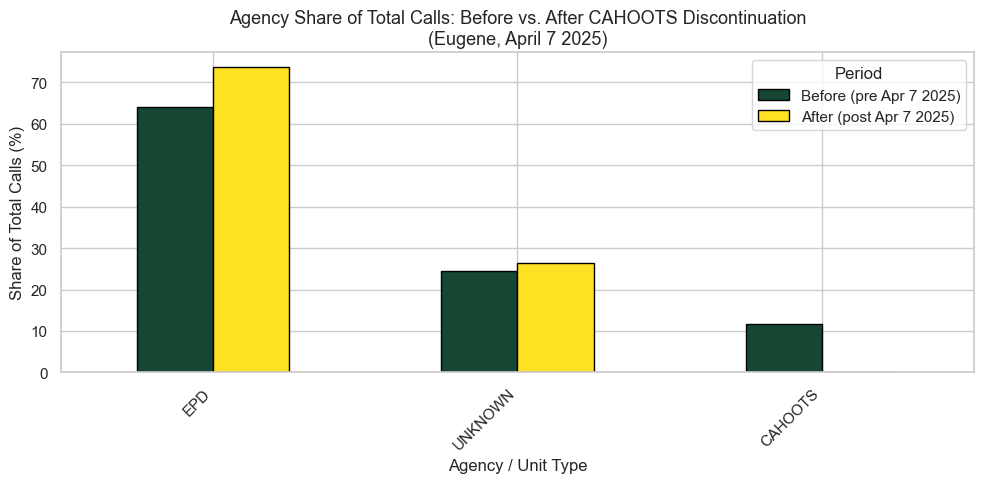

In [67]:
# Grouped bar chart: agency share before vs. after discontinuation
share_table.plot(kind='bar', figsize=(10, 5), color=['#154733', '#FEE123'], edgecolor='black')

plt.title('Agency Share of Total Calls: Before vs. After CAHOOTS Discontinuation\n(Eugene, April 7 2025)', fontsize=13)
plt.xlabel('Agency / Unit Type')
plt.ylabel('Share of Total Calls (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Period')
plt.tight_layout()
plt.savefig('figures/agency_share_pre_post.png', dpi=150)
plt.show()

### 3.3 Full Timeline: CAHOOTS and EPD Call Volumes with Discontinuation Marker

In [20]:
# Aggregate monthly call volumes for CAHOOTS and EPD
cad['year_month'] = cad['calltime'].dt.to_period('M')

timeline = (
    cad[cad['unit_type'].isin(['EPD', 'CAHOOTS'])]
    .groupby(['year_month', 'unit_type'])
    .size()
    .reset_index(name='call_count')
)

# Convert period back to timestamp for plotting
timeline['year_month'] = timeline['year_month'].dt.to_timestamp()

print(timeline.head(5))

  year_month unit_type  call_count
0 2015-01-01   CAHOOTS         807
1 2015-01-01       EPD        7627
2 2015-02-01   CAHOOTS         724
3 2015-02-01       EPD        7232
4 2015-03-01   CAHOOTS         816


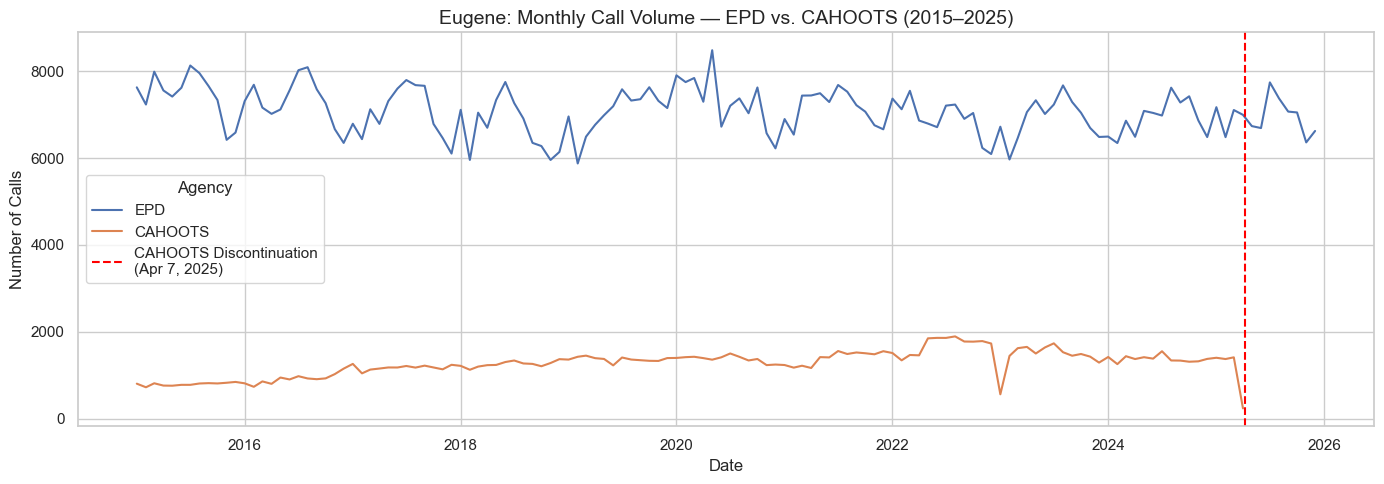

In [21]:
# Annotated line plot with discontinuation marker
fig, ax = plt.subplots(figsize=(14, 5))

for unit in ['EPD', 'CAHOOTS']:
    subset = timeline[timeline['unit_type'] == unit]
    ax.plot(subset['year_month'], subset['call_count'], label=unit, linewidth=1.5)

# Mark discontinuation date
ax.axvline(x=pd.Timestamp('2025-04-07'), color='red', linestyle='--', linewidth=1.5,
           label='CAHOOTS Discontinuation\n(Apr 7, 2025)')

ax.set_title('Eugene: Monthly Call Volume — EPD vs. CAHOOTS (2015–2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Calls')
ax.legend(title='Agency')
plt.tight_layout()
plt.savefig('figures/timeline_epd_cahoots.png', dpi=150)
plt.show()

---
## Part 4: Deeper EPD Analysis — Pre vs. Post CAHOOTS Discontinuation
*Focuses specifically on how EPD call patterns changed after April 7, 2025*

In [26]:
# Isolate EPD calls only
epd_pre  = cad_pre[cad_pre['unit_type'] == 'EPD'].copy()
epd_post = cad_post[cad_post['unit_type'] == 'EPD'].copy()

print(f'EPD calls before discontinuation: {len(epd_pre):,}')
print(f'EPD calls after discontinuation:  {len(epd_post):,}')

EPD calls before discontinuation: 872,500
EPD calls after discontinuation:  61,192


### 4.1 Average Daily EPD Call Volume — Pre vs. Post

In [27]:
# Define matched comparison windows
# Post: April 7 – Dec 31, 2025 (post-discontinuation)
# Pre:  April 7 – Dec 31, 2024 (same seasonal window, one year prior)

post_start = pd.Timestamp('2025-04-07')
post_end   = pd.Timestamp('2025-12-31')
pre_start  = pd.Timestamp('2024-04-07')
pre_end    = pd.Timestamp('2024-12-31')

epd_pre  = cad[
    (cad['unit_type'] == 'EPD') &
    (cad['calltime'] >= pre_start) &
    (cad['calltime'] <= pre_end)
].copy()

epd_post = cad[
    (cad['unit_type'] == 'EPD') &
    (cad['calltime'] >= post_start) &
    (cad['calltime'] <= post_end)
].copy()

print(f'EPD calls — Apr 7 to Dec 31, 2024 (pre):  {len(epd_pre):,}')
print(f'EPD calls — Apr 7 to Dec 31, 2025 (post): {len(epd_post):,}')
print(f'Pre period days:  {(epd_pre["calltime"].max() - epd_pre["calltime"].min()).days}')
print(f'Post period days: {(epd_post["calltime"].max() - epd_post["calltime"].min()).days}')

EPD calls — Apr 7 to Dec 31, 2024 (pre):  61,735
EPD calls — Apr 7 to Dec 31, 2025 (post): 60,939
Pre period days:  267
Post period days: 267


In [29]:
epd_pre_daily  = epd_pre.groupby(epd_pre['calltime'].dt.date).size()
epd_post_daily = epd_post.groupby(epd_post['calltime'].dt.date).size()

pre_mean  = epd_pre_daily.mean()
post_mean = epd_post_daily.mean()
pct_change = ((post_mean - pre_mean) / pre_mean) * 100

print(f'Avg daily EPD calls (Apr 7–Dec 31, 2024): {pre_mean:.1f}')
print(f'Avg daily EPD calls (Apr 7–Dec 31, 2025): {post_mean:.1f}')
print(f'Percentage change: {pct_change:+.1f}%')

Avg daily EPD calls (Apr 7–Dec 31, 2024): 230.4
Avg daily EPD calls (Apr 7–Dec 31, 2025): 227.4
Percentage change: -1.3%


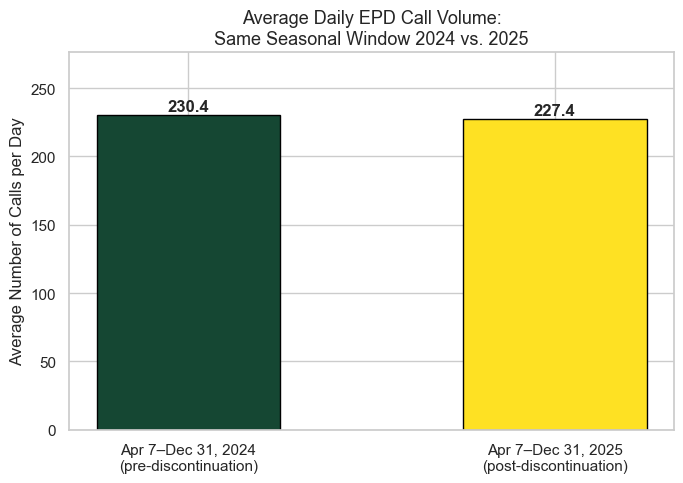

In [68]:
# Bar chart: average daily EPD call volume 2024 vs. 2025
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Apr 7–Dec 31, 2024\n(pre-discontinuation)', 'Apr 7–Dec 31, 2025\n(post-discontinuation)'],
    [pre_mean, post_mean],
    color=['#154733', '#FEE123'],
    edgecolor='black',
    width=0.5
)

for bar, val in zip(bars, [pre_mean, post_mean]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Average Daily EPD Call Volume:\nSame Seasonal Window 2024 vs. 2025', fontsize=13)
ax.set_ylabel('Average Number of Calls per Day')
ax.set_ylim(0, max(pre_mean, post_mean) * 1.2)
plt.tight_layout()
plt.savefig('figures/epd_avg_daily_2024_vs_2025.png', dpi=150)
plt.show()

### 4.2 EPD Hourly Distribution — 2024 vs. 2025 Window (KDE)


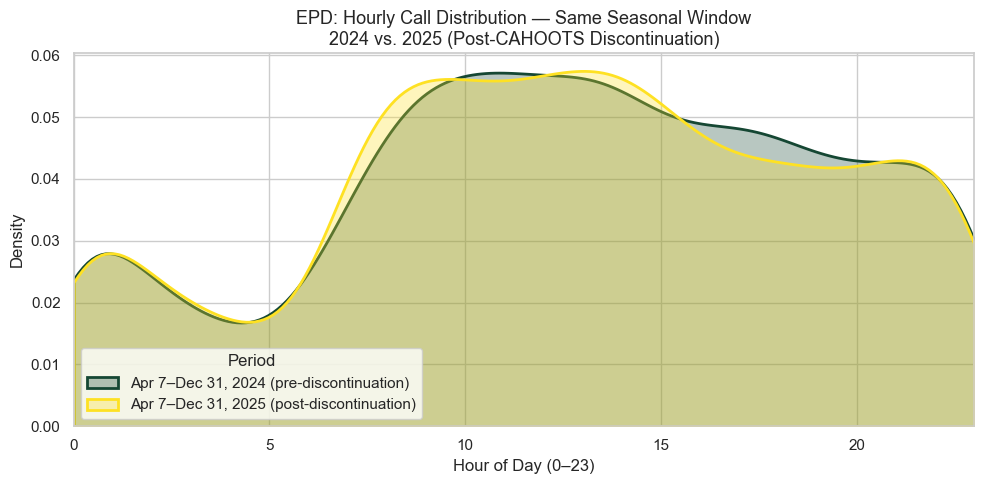

In [69]:
# KDE plot: EPD hourly distribution 2024 vs. 2025
fig, ax = plt.subplots(figsize=(10, 5))

for subset, label, color in zip(
    [epd_pre, epd_post],
    ['Apr 7–Dec 31, 2024 (pre-discontinuation)', 'Apr 7–Dec 31, 2025 (post-discontinuation)'],
    ['#154733', '#FEE123']
):
    sns.kdeplot(
        subset['call_hour'].dropna(),
        ax=ax,
        label=label,
        color=color,
        linewidth=2,
        fill=True,
        alpha=0.3,
        clip=(0, 23),
        bw_adjust=1.5
    )

ax.set_title('EPD: Hourly Call Distribution — Same Seasonal Window\n2024 vs. 2025 (Post-CAHOOTS Discontinuation)', fontsize=13)
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Density')
ax.set_xlim(0, 23)
ax.legend(title='Period')
plt.tight_layout()
plt.savefig('figures/epd_hourly_kde_2024_vs_2025.png', dpi=150)
plt.show()

---
## Part 5: UNKNOWN Call Volume Analysis
*Examines whether unclassified calls increased after CAHOOTS discontinuation,
which could suggest former CAHOOTS calls are being miscategorized*

In [37]:
# Isolate UNKNOWN calls using the same matched seasonal windows
unknown_pre = cad[
    (cad['unit_type'] == 'UNKNOWN') &
    (cad['calltime'] >= pd.Timestamp('2024-04-07')) &
    (cad['calltime'] <= pd.Timestamp('2024-12-31'))
].copy()

unknown_post = cad[
    (cad['unit_type'] == 'UNKNOWN') &
    (cad['calltime'] >= pd.Timestamp('2025-04-07')) &
    (cad['calltime'] <= pd.Timestamp('2025-12-31'))
].copy()

print(f'UNKNOWN calls — Apr 7–Dec 31, 2024: {len(unknown_pre):,}')
print(f'UNKNOWN calls — Apr 7–Dec 31, 2025: {len(unknown_post):,}')

UNKNOWN calls — Apr 7–Dec 31, 2024: 25,146
UNKNOWN calls — Apr 7–Dec 31, 2025: 21,879


### 5.1 Average Daily UNKNOWN Call Volume — 2024 vs. 2025

In [38]:
# Compute average daily UNKNOWN call volume for each window
unknown_pre_daily  = unknown_pre.groupby(unknown_pre['calltime'].dt.date).size()
unknown_post_daily = unknown_post.groupby(unknown_post['calltime'].dt.date).size()

pre_mean_unk  = unknown_pre_daily.mean()
post_mean_unk = unknown_post_daily.mean()
pct_change_unk = ((post_mean_unk - pre_mean_unk) / pre_mean_unk) * 100

print(f'Avg daily UNKNOWN calls (Apr 7–Dec 31, 2024): {pre_mean_unk:.1f}')
print(f'Avg daily UNKNOWN calls (Apr 7–Dec 31, 2025): {post_mean_unk:.1f}')
print(f'Percentage change: {pct_change_unk:+.1f}%')

Avg daily UNKNOWN calls (Apr 7–Dec 31, 2024): 93.8
Avg daily UNKNOWN calls (Apr 7–Dec 31, 2025): 81.6
Percentage change: -13.0%


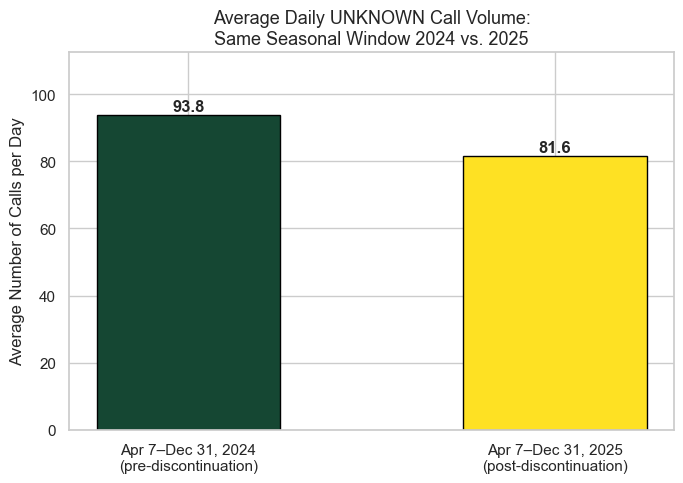

In [70]:
# Bar chart: average daily UNKNOWN call volume 2024 vs. 2025
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Apr 7–Dec 31, 2024\n(pre-discontinuation)', 'Apr 7–Dec 31, 2025\n(post-discontinuation)'],
    [pre_mean_unk, post_mean_unk],
    color=['#154733', '#FEE123'],
    edgecolor='black',
    width=0.5
)

for bar, val in zip(bars, [pre_mean_unk, post_mean_unk]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Average Daily UNKNOWN Call Volume:\nSame Seasonal Window 2024 vs. 2025', fontsize=13)
ax.set_ylabel('Average Number of Calls per Day')
ax.set_ylim(0, max(pre_mean_unk, post_mean_unk) * 1.2)
plt.tight_layout()
plt.savefig('figures/unknown_avg_daily_2024_vs_2025.png', dpi=150)
plt.show()

### 5.2 UNKNOWN Share of Total Calls — 2024 vs. 2025

UNKNOWN share of total calls (2024 window): 25.4%
UNKNOWN share of total calls (2025 window): 26.4%


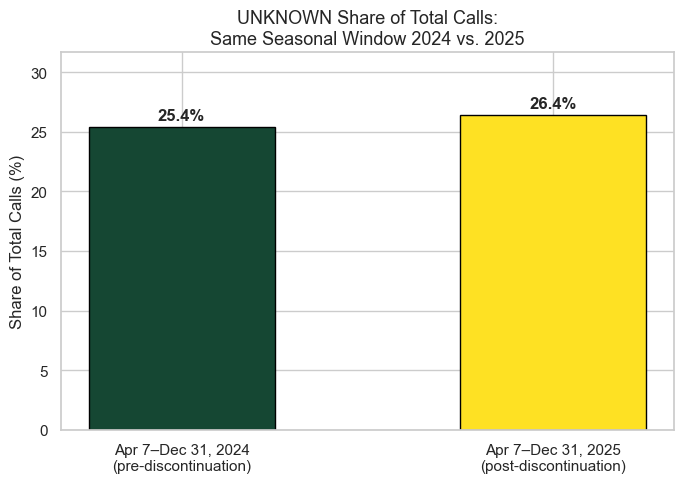

In [71]:
# Compute total calls and UNKNOWN share for each window
total_pre  = len(cad[
    (cad['calltime'] >= pd.Timestamp('2024-04-07')) &
    (cad['calltime'] <= pd.Timestamp('2024-12-31'))
])
total_post = len(cad[
    (cad['calltime'] >= pd.Timestamp('2025-04-07')) &
    (cad['calltime'] <= pd.Timestamp('2025-12-31'))
])

share_pre  = (len(unknown_pre)  / total_pre)  * 100
share_post = (len(unknown_post) / total_post) * 100

print(f'UNKNOWN share of total calls (2024 window): {share_pre:.1f}%')
print(f'UNKNOWN share of total calls (2025 window): {share_post:.1f}%')

# Bar chart: UNKNOWN share of total calls
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Apr 7–Dec 31, 2024\n(pre-discontinuation)', 'Apr 7–Dec 31, 2025\n(post-discontinuation)'],
    [share_pre, share_post],
    color=['#154733', '#FEE123'],
    edgecolor='black',
    width=0.5
)

for bar, val in zip(bars, [share_pre, share_post]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('UNKNOWN Share of Total Calls:\nSame Seasonal Window 2024 vs. 2025', fontsize=13)
ax.set_ylabel('Share of Total Calls (%)')
ax.set_ylim(0, max(share_pre, share_post) * 1.2)
plt.tight_layout()
plt.savefig('figures/unknown_share_2024_vs_2025.png', dpi=150)
plt.show()

### 5.3 UNKNOWN Hourly Distribution — 2024 vs. 2025 (KDE)

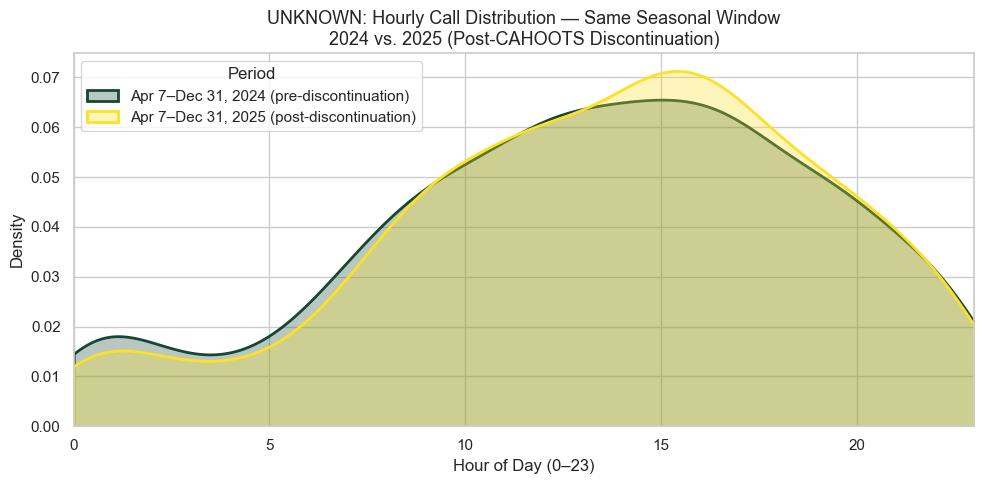

In [72]:
# KDE plot: UNKNOWN hourly distribution 2024 vs. 2025
fig, ax = plt.subplots(figsize=(10, 5))

for subset, label, color in zip(
    [unknown_pre, unknown_post],
    ['Apr 7–Dec 31, 2024 (pre-discontinuation)', 'Apr 7–Dec 31, 2025 (post-discontinuation)'],
    ['#154733', '#FEE123']
):
    sns.kdeplot(
        subset['call_hour'].dropna(),
        ax=ax,
        label=label,
        color=color,
        linewidth=2,
        fill=True,
        alpha=0.3,
        clip=(0, 23),
        bw_adjust=1.5
    )

ax.set_title('UNKNOWN: Hourly Call Distribution — Same Seasonal Window\n2024 vs. 2025 (Post-CAHOOTS Discontinuation)', fontsize=13)
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Density')
ax.set_xlim(0, 23)
ax.legend(title='Period')
plt.tight_layout()
plt.savefig('figures/unknown_hourly_kde_2024_vs_2025.png', dpi=150)
plt.show()

---
## Part 6: Springfield CAHOOTS as Control
*Compares Springfield CAHOOTS call volumes in the same seasonal windows.
If Springfield stayed stable while Eugene dropped to zero, this strengthens
the argument that the Eugene drop was caused by the discontinuation.*

In [45]:
# Isolate Springfield CAHOOTS calls using the same matched windows
spd_cahoots_pre = spd[
    (spd['unit_type'] == 'CAHOOTS') &
    (spd['calltime'] >= pd.Timestamp('2024-04-07')) &
    (spd['calltime'] <= pd.Timestamp('2024-12-31'))
].copy()

spd_cahoots_post = spd[
    (spd['unit_type'] == 'CAHOOTS') &
    (spd['calltime'] >= pd.Timestamp('2025-04-07')) &
    (spd['calltime'] <= pd.Timestamp('2025-12-31'))
].copy()

print(f'Springfield CAHOOTS calls — Apr 7–Dec 31, 2024: {len(spd_cahoots_pre):,}')
print(f'Springfield CAHOOTS calls — Apr 7–Dec 31, 2025: {len(spd_cahoots_post):,}')

Springfield CAHOOTS calls — Apr 7–Dec 31, 2024: 2,263
Springfield CAHOOTS calls — Apr 7–Dec 31, 2025: 1,630


### 6.1 Average Daily Springfield CAHOOTS Call Volume — 2024 vs. 2025

In [46]:
# Compute average daily call volume for each window
spd_pre_daily  = spd_cahoots_pre.groupby(spd_cahoots_pre['calltime'].dt.date).size()
spd_post_daily = spd_cahoots_post.groupby(spd_cahoots_post['calltime'].dt.date).size()

spd_pre_mean   = spd_pre_daily.mean()
spd_post_mean  = spd_post_daily.mean()
spd_pct_change = ((spd_post_mean - spd_pre_mean) / spd_pre_mean) * 100

print(f'Avg daily Springfield CAHOOTS calls (Apr 7–Dec 31, 2024): {spd_pre_mean:.1f}')
print(f'Avg daily Springfield CAHOOTS calls (Apr 7–Dec 31, 2025): {spd_post_mean:.1f}')
print(f'Percentage change: {spd_pct_change:+.1f}%')

Avg daily Springfield CAHOOTS calls (Apr 7–Dec 31, 2024): 8.5
Avg daily Springfield CAHOOTS calls (Apr 7–Dec 31, 2025): 7.1
Percentage change: -17.1%


In [52]:
# Side by side bar chart: Eugene CAHOOTS vs Springfield CAHOOTS 2024 vs 2025
# Pull Eugene CAHOOTS daily averages from the same windows for direct comparison
eugene_cahoots_pre = cad[
    (cad['unit_type'] == 'CAHOOTS') &
    (cad['calltime'] >= pd.Timestamp('2024-04-07')) &
    (cad['calltime'] <= pd.Timestamp('2024-12-31'))
]
eugene_cahoots_post = cad[
    (cad['unit_type'] == 'CAHOOTS') &
    (cad['calltime'] >= pd.Timestamp('2025-04-07')) &
    (cad['calltime'] <= pd.Timestamp('2025-12-31'))
]

eugene_pre_mean  = eugene_cahoots_pre.groupby(eugene_cahoots_pre['calltime'].dt.date).size().mean()
eugene_post_mean = eugene_cahoots_post.groupby(eugene_cahoots_post['calltime'].dt.date).size().mean()

print(f'\nAvg daily Eugene CAHOOTS calls (Apr 7–Dec 31, 2024): {eugene_pre_mean:.1f}')
print(f'Avg daily Eugene CAHOOTS calls (Apr 7–Dec 31, 2025): {eugene_post_mean:.1f}')


Avg daily Eugene CAHOOTS calls (Apr 7–Dec 31, 2024): 45.1
Avg daily Eugene CAHOOTS calls (Apr 7–Dec 31, 2025): 7.0


,inci_id,calltime,primeunit,call_year,call_month,call_day,call_hour,call_dow,unit_type,year_month
1362890,25088800,2025-04-07 01:48:00,_4J79,2025,4,7,1,Monday,CAHOOTS,2025-04
1362891,25088802,2025-04-07 01:56:26,_4J79,2025,4,7,1,Monday,CAHOOTS,2025-04
1362895,25088809,2025-04-07 02:16:27,_CAHOT,2025,4,7,2,Monday,CAHOOTS,2025-04
1362900,25088831,2025-04-07 02:54:53,_4J79,2025,4,7,2,Monday,CAHOOTS,2025-04
1362904,25088848,2025-04-07 03:21:06,_4J79,2025,4,7,3,Monday,CAHOOTS,2025-04
1362909,25088860,2025-04-07 03:49:10,_4J79,2025,4,7,3,Monday,CAHOOTS,2025-04
1362910,25088867,2025-04-07 04:33:08,_4J79,2025,4,7,4,Monday,CAHOOTS,2025-04


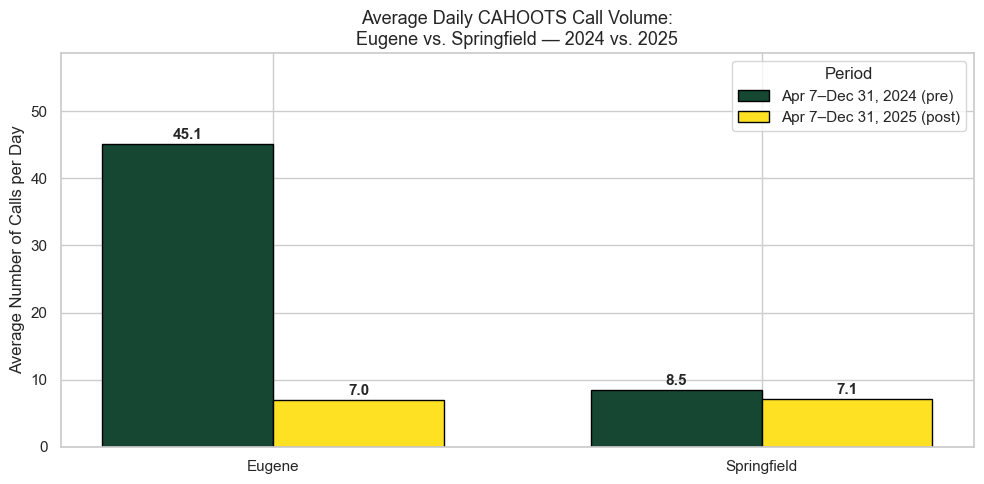

In [73]:
# Grouped bar chart: Eugene vs Springfield CAHOOTS 2024 vs 2025
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(2)
width = 0.35

bars_2024 = ax.bar(x - width/2, [eugene_pre_mean, spd_pre_mean],
                   width, label='Apr 7–Dec 31, 2024 (pre)',
                   color='#154733', edgecolor='black')
bars_2025 = ax.bar(x + width/2, [eugene_post_mean, spd_post_mean],
                   width, label='Apr 7–Dec 31, 2025 (post)',
                   color='#FEE123', edgecolor='black')

# Value labels
for bar in bars_2024:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
for bar in bars_2025:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Average Daily CAHOOTS Call Volume:\nEugene vs. Springfield — 2024 vs. 2025', fontsize=13)
ax.set_ylabel('Average Number of Calls per Day')
ax.set_xticks(x)
ax.set_xticklabels(['Eugene', 'Springfield'])
ax.legend(title='Period')
ax.set_ylim(0, max(eugene_pre_mean, spd_pre_mean) * 1.3)
plt.tight_layout()
plt.savefig('figures/cahoots_eugene_vs_spd_2024_vs_2025.png', dpi=150)
plt.show()

### 6.2 Springfield CAHOOTS Hourly Distribution — 2024 vs. 2025 (KDE)


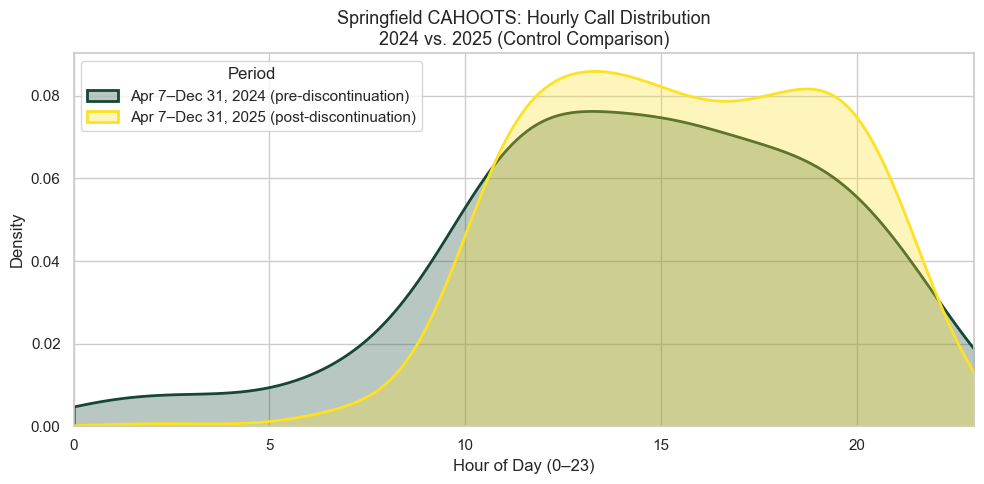

In [74]:
# KDE: Springfield CAHOOTS hourly distribution 2024 vs 2025
fig, ax = plt.subplots(figsize=(10, 5))

for subset, label, color in zip(
    [spd_cahoots_pre, spd_cahoots_post],
    ['Apr 7–Dec 31, 2024 (pre-discontinuation)', 'Apr 7–Dec 31, 2025 (post-discontinuation)'],
    ['#154733', '#FEE123']
):
    sns.kdeplot(
        subset['call_hour'].dropna(),
        ax=ax,
        label=label,
        color=color,
        linewidth=2,
        fill=True,
        alpha=0.3,
        clip=(0, 23),
        bw_adjust=1.5
    )

ax.set_title('Springfield CAHOOTS: Hourly Call Distribution\n2024 vs. 2025 (Control Comparison)', fontsize=13)
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Density')
ax.set_xlim(0, 23)
ax.legend(title='Period')
plt.tight_layout()
plt.savefig('figures/spd_cahoots_hourly_kde_2024_vs_2025.png', dpi=150)
plt.show()